In [2]:
# Importamos las librerías necesarias
import requests
import pandas as pd
import time
from datetime import datetime, timedelta
import uuid
import pymysql
import folium
import json
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [8]:

# Constantes de configuración de la API REE
BASE_URL = "https://apidatos.ree.es/es/datos/"

HEADERS = {
    "accept": "application/json",
    "content-type": "application/json"
}

ENDPOINTS = {
    "demanda": ("demanda/evolucion", "hour"),
    "balance": ("balance/balance-electrico", "day"),
    "generacion": ("generacion/evolucion-renovable-no-renovable", "day"),
    "intercambios": ("intercambios/todas-fronteras-programados", "day"),
    "intercambios_baleares": ("intercambios/enlace-baleares", "day"),
}

# Función para consultar un endpoint, según los parámetros dados, de la API de REE 
def get_data(endpoint_name, endpoint_info, params):
    path, time_trunc = endpoint_info
    params["time_trunc"] = time_trunc
    url = BASE_URL + path

    try:
        response = requests.get(url, headers=HEADERS, params=params)
        # Si la búsqueda no fue bien, se devuelve una lista vacía
        if response.status_code != 200:
            return []
        response_data = response.json()
    except Exception:
        return []

    data = []

    # Verificamos si el item tiene "content" y asumimos que es una estructura compleja
    for item in response_data.get("included", []):
        attrs = item.get("attributes", {})
        category = attrs.get("title")

        if "content" in attrs:
            for sub in attrs["content"]:
                sub_attrs = sub.get("attributes", {})
                sub_cat = sub_attrs.get("title")
                for entry in sub_attrs.get("values", []):
                    entry["primary_category"] = category
                    entry["sub_category"] = sub_cat
                    data.append(entry)
        else:
            # Procesamos las estructuras más simples (demanda, generacion, intercambios_baleares), asumiendo que no hay subcategorías
            for entry in attrs.get("values", []):
                entry["primary_category"] = category
                entry["sub_category"] = None
                data.append(entry)

    return data

# Función de extracción de datos de los últimos x años, devuelve un DataFrame de Pandas
def get_data_for_last_x_years(num_years=3):
    all_dfs = []
    current_date = datetime.now()
    # Calculamos el año de inicio a partir del año actual
    start_year_limit = current_date.year - num_years

    # Iteramos sobre cada año y mes
    for year in range(start_year_limit, current_date.year + 1):
        for month in range(1, 13):
            # Si el mes es mayor al mes actual y el año es el actual, lo saltamos
            month_start = datetime(year, month, 1)
            if month_start > current_date:
                continue

            # Calculamos el final del mes, asegurándonos de no exceder la fecha actual
            month_end = (month_start + timedelta(days=32)).replace(day=1) - timedelta(minutes=1)
            end_date_for_request = min(month_end, current_date)

            # Iteramos sobre cada endpoint
            for name, (path, granularity) in ENDPOINTS.items():
                params = {
                    "start_date": month_start.strftime("%Y-%m-%dT%H:%M"),
                    "end_date": end_date_for_request.strftime("%Y-%m-%dT%H:%M"),
                    "geo_trunc": "electric_system",
                    "geo_limit": "peninsular",
                    "geo_ids": "8741"
                }

                month_data = get_data(name, (path, granularity), params)

                # Y sacamos los datos
                if month_data:
                    df = pd.DataFrame(month_data)
                    #Lidiamos con problemas de zona horaria en la columna "datetime"
                    try:
                        df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
                    except Exception:
                        continue
                    
                    # Obtenemos nuevas columnas y las reordenamos
                    df['year'] = df['datetime'].dt.year
                    df['month'] = df['datetime'].dt.month
                    df['day'] = df['datetime'].dt.day
                    df['hour'] = df['datetime'].dt.hour
                    df['endpoint'] = name
                    df['extraction_timestamp'] = datetime.utcnow()
                    df['record_id'] = [str(uuid.uuid4()) for _ in range(len(df))]

                    df = df[['record_id', 'value', 'percentage', 'datetime',
                             'primary_category', 'sub_category', 'year', 'month',
                             'day', 'hour', 'endpoint', 'extraction_timestamp']]

                    all_dfs.append(df)

                time.sleep(1)

    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()

# Obtenemos los datos de los últimos 3 años a partir de hoy
ree_data_df = get_data_for_last_x_years(num_years=3)

df_demanda = ree_data_df[ree_data_df["endpoint"] == "demanda"].drop(columns=["endpoint", "sub_category"])
df_balance = ree_data_df[ree_data_df["endpoint"] == "balance"].drop(columns=["endpoint"])
df_generacion = ree_data_df[ree_data_df["endpoint"] == "generacion"].drop(columns=["endpoint", "sub_category"])
df_intercambios = ree_data_df[ree_data_df["endpoint"] == "intercambios"].drop(columns=["endpoint"])
df_intercambios_baleares = ree_data_df[ree_data_df["endpoint"] == "intercambios_baleares"].drop(columns=["endpoint", "sub_category"])


C:\Users\Adri\AppData\Local\Temp\ipykernel_952\1144382035.py:102: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  df['extraction_timestamp'] = datetime.utcnow()
C:\Users\Adri\AppData\Local\Temp\ipykernel_952\1144382035.py:102: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  df['extraction_timestamp'] = datetime.utcnow()
C:\Users\Adri\AppData\Local\Temp\ipykernel_952\1144382035.py:102: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  df['extraction_timestamp'] = datetime.utcnow()
C:\Users\Adri\AppData\Local\Temp\ipykernel_952

In [10]:
ree_data_df

,record_id,value,percentage,datetime,primary_category,sub_category,year,month,day,hour,endpoint,extraction_timestamp
0,81bea1bf-cb72-4107-a7e4-7835a06c2ba0,21302.252,1.0,2021-12-31 23:00:00+00:00,Demanda,None,2021,12,31,23,demanda,2025-06-03 17:52:15.821279
1,5b84b92b-d1c2-4196-9414-d286cd5a159a,20605.178,1.0,2022-01-01 00:00:00+00:00,Demanda,None,2022,1,1,0,demanda,2025-06-03 17:52:15.821279
2,535bda56-0055-4b20-a50e-2a9fd87b5497,19293.080,1.0,2022-01-01 01:00:00+00:00,Demanda,None,2022,1,1,1,demanda,2025-06-03 17:52:15.821279
3,2a0fc6fb-676e-4be3-9503-feb0e6091b2e,18171.107,1.0,2022-01-01 02:00:00+00:00,Demanda,None,2022,1,1,2,demanda,2025-06-03 17:52:15.821279
4,202fbddf-79da-4e4c-8a41-ce9195739125,17481.447,1.0,2022-01-01 03:00:00+00:00,Demanda,None,2022,1,1,3,demanda,2025-06-03 17:52:15.821279
...,...,...,...,...,...,...,...,...,...,...,...,...
73277,99b2efa8-82de-4b51-b5e5-961786622599,-4741.000,0.5,2025-06-01 22:00:00+00:00,Salidas,None,2025,6,1,22,intercambios_baleares,2025-06-03 17:58:25.622569
73278,3efad76f-09ea-40aa-b5e7-09a7d74b3cb4,-3432.000,0.5,2025-06-02 22:00:00+00:00,Salidas,None,2025,6,2,22,intercambios_baleares,2025-06-03 17:58:25.622569
73279,4267c288-bc06-46c4-a279-da1756d432a0,-3993.000,0.5,2025-05-31 22:00:00+00:00,Entradas,None,2025,5,31,22,intercambios_baleares,2025-06-03 17:58:25.622569
73280,e4ede7ec-ff88-4ec5-a731-b43e47dd7764,-4741.000,0.5,2025-06-01 22:00:00+00:00,Entradas,None,2025,6,1,22,intercambios_baleares,2025-06-03 17:58:25.622569


In [12]:
ree_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73282 entries, 0 to 73281
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   record_id             73282 non-null  object             
 1   value                 73282 non-null  float64            
 2   percentage            73282 non-null  float64            
 3   datetime              73282 non-null  datetime64[ns, UTC]
 4   primary_category      73282 non-null  object             
 5   sub_category          38293 non-null  object             
 6   year                  73282 non-null  int32              
 7   month                 73282 non-null  int32              
 8   day                   73282 non-null  int32              
 9   hour                  73282 non-null  int32              
 10  endpoint              73282 non-null  object             
 11  extraction_timestamp  73282 non-null  datetime64[us]     
dtypes: d

In [14]:
df_demanda

,record_id,value,percentage,datetime,primary_category,year,month,day,hour,extraction_timestamp
0,81bea1bf-cb72-4107-a7e4-7835a06c2ba0,21302.252,1.0,2021-12-31 23:00:00+00:00,Demanda,2021,12,31,23,2025-06-03 17:52:15.821279
1,5b84b92b-d1c2-4196-9414-d286cd5a159a,20605.178,1.0,2022-01-01 00:00:00+00:00,Demanda,2022,1,1,0,2025-06-03 17:52:15.821279
2,535bda56-0055-4b20-a50e-2a9fd87b5497,19293.080,1.0,2022-01-01 01:00:00+00:00,Demanda,2022,1,1,1,2025-06-03 17:52:15.821279
3,2a0fc6fb-676e-4be3-9503-feb0e6091b2e,18171.107,1.0,2022-01-01 02:00:00+00:00,Demanda,2022,1,1,2,2025-06-03 17:52:15.821279
4,202fbddf-79da-4e4c-8a41-ce9195739125,17481.447,1.0,2022-01-01 03:00:00+00:00,Demanda,2022,1,1,3,2025-06-03 17:52:15.821279
...,...,...,...,...,...,...,...,...,...,...
73177,ae7212c1-825a-4d22-ab4c-ece0daa3ea29,27847.500,1.0,2025-06-03 13:00:00+00:00,Demanda,2025,6,3,13,2025-06-03 17:58:18.901145
73178,410572e4-752c-4b03-b639-1629a79c0a8a,27717.000,1.0,2025-06-03 14:00:00+00:00,Demanda,2025,6,3,14,2025-06-03 17:58:18.901145
73179,53d7784b-5fb8-4fc3-b63f-d74b3887a668,28342.300,1.0,2025-06-03 15:00:00+00:00,Demanda,2025,6,3,15,2025-06-03 17:58:18.901145
73180,d1e01dbd-5eca-47ed-bcc0-aff786103af8,28853.500,1.0,2025-06-03 16:00:00+00:00,Demanda,2025,6,3,16,2025-06-03 17:58:18.901145


In [16]:
df_balance

,record_id,value,percentage,datetime,primary_category,sub_category,year,month,day,hour,extraction_timestamp
744,0d1619f6-2787-4e9c-a6c6-6549c7998479,49971.047,0.194179,2021-12-31 23:00:00+00:00,Renovable,Hidráulica,2021,12,31,23,2025-06-03 17:52:17.705803
745,7a56b73a-b40a-4b10-a579-ef43c9439c02,52663.908,0.240484,2022-01-01 23:00:00+00:00,Renovable,Hidráulica,2022,1,1,23,2025-06-03 17:52:17.705803
746,6e93c567-31e4-4130-84cf-e704596130ac,53068.508,0.193899,2022-01-02 23:00:00+00:00,Renovable,Hidráulica,2022,1,2,23,2025-06-03 17:52:17.705803
747,dddb03a2-ed0b-4a09-aaa4-09b33c7a668d,51497.125,0.128910,2022-01-03 23:00:00+00:00,Renovable,Hidráulica,2022,1,3,23,2025-06-03 17:52:17.705803
748,a81ffb5c-8478-4ac5-b3f9-a4fc4fb06bed,57195.362,0.143566,2022-01-04 23:00:00+00:00,Renovable,Hidráulica,2022,1,4,23,2025-06-03 17:52:17.705803
...,...,...,...,...,...,...,...,...,...,...,...
73234,0cc7fcf9-6395-4370-9c5c-632c303e3574,-40872.600,0.052702,2025-06-01 22:00:00+00:00,Demanda,Saldo I. internacionales,2025,6,1,22,2025-06-03 17:58:20.797201
73235,3ea5f474-05e0-4248-8bdb-21cc445dd315,3102.600,0.005464,2025-06-02 22:00:00+00:00,Demanda,Saldo I. internacionales,2025,6,2,22,2025-06-03 17:58:20.797201
73236,52865c2e-d86f-4369-b38e-5ae79070ce1b,555829.600,1.000000,2025-05-31 22:00:00+00:00,Demanda,Demanda en b.c.,2025,5,31,22,2025-06-03 17:58:20.797201
73237,2725e43c-29d7-416f-81c4-89b14d46af0f,654338.000,1.000000,2025-06-01 22:00:00+00:00,Demanda,Demanda en b.c.,2025,6,1,22,2025-06-03 17:58:20.797201


In [18]:
df_generacion

,record_id,value,percentage,datetime,primary_category,year,month,day,hour,extraction_timestamp
1333,90745ce4-153d-4687-bdc6-34cd789d36d8,257345.8145,0.497897,2021-12-31 23:00:00+00:00,Renovable,2021,12,31,23,2025-06-03 17:52:19.369068
1334,3c54f15f-e53b-4c21-8e92-b573e03863cc,218991.3890,0.407407,2022-01-01 23:00:00+00:00,Renovable,2022,1,1,23,2025-06-03 17:52:19.369068
1335,c69d85b2-b99d-404b-9048-bfde02bf7554,273691.1820,0.439420,2022-01-02 23:00:00+00:00,Renovable,2022,1,2,23,2025-06-03 17:52:19.369068
1336,fed56ae9-7b1c-4fda-90b0-24e6fc1079e6,399481.4875,0.571029,2022-01-03 23:00:00+00:00,Renovable,2022,1,3,23,2025-06-03 17:52:19.369068
1337,6ce691da-0d2e-474d-b6ce-3e9dc95f59c9,398390.3575,0.557618,2022-01-04 23:00:00+00:00,Renovable,2022,1,4,23,2025-06-03 17:52:19.369068
...,...,...,...,...,...,...,...,...,...,...
73240,98d914df-0d0b-4d0b-8233-cd5abc344dc5,458240.1000,0.640952,2025-06-01 22:00:00+00:00,Renovable,2025,6,1,22,2025-06-03 17:58:22.345503
73241,1752372f-d9ef-4b6b-81df-af50b993e8f2,344912.0500,0.630672,2025-06-02 22:00:00+00:00,Renovable,2025,6,2,22,2025-06-03 17:58:22.345503
73242,5d0ada8e-e545-40aa-84c7-97d7a1508680,257309.4000,0.413308,2025-05-31 22:00:00+00:00,No renovable,2025,5,31,22,2025-06-03 17:58:22.345503
73243,e547fad4-40d4-4e3f-b3f5-8b3bc46fbf9d,256697.0000,0.359048,2025-06-01 22:00:00+00:00,No renovable,2025,6,1,22,2025-06-03 17:58:22.345503


In [20]:
df_intercambios

,record_id,value,percentage,datetime,primary_category,sub_category,year,month,day,hour,extraction_timestamp
1395,464c408f-7785-4156-a06d-1aef4a3f9174,-2873.3,0.040691,2021-12-31 23:00:00+00:00,francia,Exportación,2021,12,31,23,2025-06-03 17:52:21.000159
1396,96cf30ed-8526-46bc-91af-74af1f8dca8b,-2674.3,0.033530,2022-01-01 23:00:00+00:00,francia,Exportación,2022,1,1,23,2025-06-03 17:52:21.000159
1397,b6d7ca32-d6b2-4202-872a-68227138b89b,-6444.3,0.078966,2022-01-02 23:00:00+00:00,francia,Exportación,2022,1,2,23,2025-06-03 17:52:21.000159
1398,f8af4312-7a96-4278-b901-9d4a3ce88e50,-41761.7,0.727676,2022-01-03 23:00:00+00:00,francia,Exportación,2022,1,3,23,2025-06-03 17:52:21.000159
1399,7c44d963-1794-47d9-8f63-0fe526de737f,-42497.1,0.801499,2022-01-04 23:00:00+00:00,francia,Exportación,2022,1,4,23,2025-06-03 17:52:21.000159
...,...,...,...,...,...,...,...,...,...,...,...
73271,61b1ad63-7fa4-457c-9d7c-7194c596ec26,-188.0,1.000000,2025-06-01 22:00:00+00:00,andorra,Exportación,2025,6,1,22,2025-06-03 17:58:24.294562
73272,7f56e1cb-aadd-40f0-b5d6-5bfc369e17b8,-197.3,1.000000,2025-06-02 22:00:00+00:00,andorra,Exportación,2025,6,2,22,2025-06-03 17:58:24.294562
73273,d84ecc16-f7a2-415a-84bf-b92ccf28fe87,-199.6,1.000000,2025-05-31 22:00:00+00:00,andorra,saldo,2025,5,31,22,2025-06-03 17:58:24.294562
73274,a9ddbcf5-d706-4bda-85ec-558bcf7d4f06,-188.0,1.000000,2025-06-01 22:00:00+00:00,andorra,saldo,2025,6,1,22,2025-06-03 17:58:24.294562


In [22]:
df_intercambios_baleares

,record_id,value,percentage,datetime,primary_category,year,month,day,hour,extraction_timestamp
1729,e6c842ab-3a40-4197-a839-202382566d42,-1004.659,0.5,2021-12-31 23:00:00+00:00,Salidas,2021,12,31,23,2025-06-03 17:52:22.706471
1730,13a9882d-bc16-4269-843d-0ca311e1e7e0,-1004.140,0.5,2022-01-01 23:00:00+00:00,Salidas,2022,1,1,23,2025-06-03 17:52:22.706471
1731,3a3c617d-2442-49b7-86a1-a9b0c52fe335,-1003.493,0.5,2022-01-02 23:00:00+00:00,Salidas,2022,1,2,23,2025-06-03 17:52:22.706471
1732,c35cce75-fdfd-4b02-9d45-f3b17806cde8,-1003.752,0.5,2022-01-03 23:00:00+00:00,Salidas,2022,1,3,23,2025-06-03 17:52:22.706471
1733,cd9fc89c-2274-4ecc-9f17-466db2d6ae21,-1003.753,0.5,2022-01-04 23:00:00+00:00,Salidas,2022,1,4,23,2025-06-03 17:52:22.706471
...,...,...,...,...,...,...,...,...,...,...
73277,99b2efa8-82de-4b51-b5e5-961786622599,-4741.000,0.5,2025-06-01 22:00:00+00:00,Salidas,2025,6,1,22,2025-06-03 17:58:25.622569
73278,3efad76f-09ea-40aa-b5e7-09a7d74b3cb4,-3432.000,0.5,2025-06-02 22:00:00+00:00,Salidas,2025,6,2,22,2025-06-03 17:58:25.622569
73279,4267c288-bc06-46c4-a279-da1756d432a0,-3993.000,0.5,2025-05-31 22:00:00+00:00,Entradas,2025,5,31,22,2025-06-03 17:58:25.622569
73280,e4ede7ec-ff88-4ec5-a731-b43e47dd7764,-4741.000,0.5,2025-06-01 22:00:00+00:00,Entradas,2025,6,1,22,2025-06-03 17:58:25.622569


In [24]:

# Conexión a la base de datos
database = "ree"

# Diccionario tabla -> DataFrame
tablas_dfs = {
    "demanda": df_demanda,
    "generacion": df_generacion,
    "balance": df_balance,
    "intercambios": df_intercambios,
    "intercambios_baleares": df_intercambios_baleares
}

batch_size = 1000

db = pymysql.connect(
    host='localhost',
    user='root',
    password='Password',
    database=database
)

cursor = db.cursor()

for tabla, df in tablas_dfs.items():
    # Obtener nombres de columnas desde la tabla destino
    cursor.execute(f"SELECT * FROM {tabla} LIMIT 0;")
    column_names = [col[0] for col in cursor.description]

    # Preparar la query de inserción
    insert_query = (
        f"INSERT INTO {tabla} ({', '.join(column_names)}) "
        f"VALUES ({', '.join(['%s'] * len(column_names))})"
    )

    # Reemplazar NaN por None
    df = df.where(pd.notnull(df), None)

    # Ordenar columnas como en la tabla
    values = [tuple(row) for row in df[column_names].values]

    # Insertar en lotes
    for i in range(0, len(values), batch_size):
        batch = values[i: i + batch_size]
        try:
            cursor.executemany(insert_query, batch)
            db.commit()
            print(f"Añadidas: {cursor.rowcount} filas en '{tabla}' (Batch {i // batch_size + 1})")
        except Exception as e:
            print(f"Error al insertar en '{tabla}' (Batch {i // batch_size + 1}): {e}")
            db.rollback()

cursor.close()
db.close()

Añadidas: 1000 filas en 'demanda' (Batch 1)
Añadidas: 1000 filas en 'demanda' (Batch 2)
Añadidas: 1000 filas en 'demanda' (Batch 3)
Añadidas: 1000 filas en 'demanda' (Batch 4)
Añadidas: 1000 filas en 'demanda' (Batch 5)
Añadidas: 1000 filas en 'demanda' (Batch 6)
Añadidas: 1000 filas en 'demanda' (Batch 7)
Añadidas: 1000 filas en 'demanda' (Batch 8)
Añadidas: 1000 filas en 'demanda' (Batch 9)
Añadidas: 1000 filas en 'demanda' (Batch 10)
Añadidas: 1000 filas en 'demanda' (Batch 11)
Añadidas: 1000 filas en 'demanda' (Batch 12)
Añadidas: 1000 filas en 'demanda' (Batch 13)
Añadidas: 1000 filas en 'demanda' (Batch 14)
Añadidas: 1000 filas en 'demanda' (Batch 15)
Añadidas: 1000 filas en 'demanda' (Batch 16)
Añadidas: 1000 filas en 'demanda' (Batch 17)
Añadidas: 1000 filas en 'demanda' (Batch 18)
Añadidas: 1000 filas en 'demanda' (Batch 19)
Añadidas: 1000 filas en 'demanda' (Batch 20)
Añadidas: 1000 filas en 'demanda' (Batch 21)
Añadidas: 1000 filas en 'demanda' (Batch 22)
Añadidas: 1000 fila

ProgrammingError: (1146, "Table 'ree.intercambios_baleares' doesn't exist")

In [26]:
# Conexión a la base de datos
db = pymysql.connect(
    host = 'localhost',
    user = 'root',
    password = 'Password',  # OJO que sea tu contraseña
    database = database
)

# Función para ejecutar consultas y devolver DataFrames
def consulta(sql):
    return pd.read_sql(sql, con=db)

# Consultas SQL para obtener datos de la base de datos

# Demanda media por hora (2023)
demanda_por_hora = consulta("""
SELECT hour, ROUND(AVG(value), 2) AS demanda_media
FROM demanda
WHERE year = 2023
GROUP BY hour
ORDER BY hour;
""")
print("\n Demanda media por hora (2023):")
print(demanda_por_hora)

# Generación media mensual por año
generacion_mensual = consulta("""
SELECT year, month, ROUND(AVG(value), 2) AS generacion_media
FROM generacion
GROUP BY year, month
ORDER BY year, month;
""")
print("\n Generación media mensual:")
print(generacion_mensual)

# Balance medio por subcategoría en 2022
balance_subcat = consulta("""
SELECT sub_category, ROUND(AVG(value), 2) AS balance_medio
FROM balance
WHERE year = 2022
GROUP BY sub_category
ORDER BY balance_medio DESC;
""")
print("\n Balance por subcategoría (2022):")
print(balance_subcat)

#################### He arreglado esta query, que sacab el tipo de intercambio en lugar de la frontera
# Intercambios acumulados por frontera
intercambios_total = consulta("""
SELECT primary_category AS frontera, ROUND(SUM(value), 2) AS saldo_total
FROM intercambios
GROUP BY primary_category
ORDER BY saldo_total;
""")
print("\n Intercambios por frontera:")
print(intercambios_total)

####################### He añadido esta query con la nueva tabla de nuestra BBDD
# Intercambios con las Islas Baleares
intercambios_total = consulta("""
SELECT primary_category AS intercambio, ROUND(SUM(value), 2) AS saldo_total
FROM intercambios_baleares
GROUP BY primary_category
ORDER BY saldo_total;
""")
print("\n Intercambios por frontera:")
print(intercambios_total)

# Día con mayor demanda registrada
mayor_demanda = consulta("""
SELECT DATE(datetime) AS fecha, SUM(value) AS total_diario
FROM demanda
GROUP BY fecha
ORDER BY total_diario DESC
LIMIT 1;
""")
print("\n Día con mayor demanda:")
print(mayor_demanda)

####################### No tenemos datos de tan atrás, eliminaría esta query o la cambiaría por algún otro suceso más reciente
#  Comparativa de demanda entre 2019 y 2023
comparativa_demanda = consulta("""
SELECT year, ROUND(AVG(value), 2) AS media_demanda
FROM demanda
WHERE year IN (2019, 2023)
GROUP BY year;
""")
print("\n Comparativa prepandemia vs 2023:")
print(comparativa_demanda)

#################### He arreglado esta query para que mostrase lo que dice el título
#  Importaciones totales por país
importaciones = consulta("""
SELECT primary_category AS pais, SUM(value) AS total_importado
FROM intercambios
WHERE sub_category LIKE "Importación"
GROUP BY pais
ORDER BY total_importado DESC;
""")
print("\n Importaciones por país:")
print(importaciones)

#################### He arreglado esta query para que mostrase lo que dice el título
#  Exportaciones totales por país
exportaciones = consulta("""
SELECT primary_category AS pais, SUM(value) AS total_importado
FROM intercambios
WHERE sub_category LIKE "Exportación"
GROUP BY pais
ORDER BY total_importado DESC;
""")
print("\n Exportaciones por país:")
print(exportaciones)

# Media de demanda por día de la semana
demanda_dia_semana = consulta("""
SELECT DAYNAME(datetime) AS dia, ROUND(AVG(value), 2) AS media_demanda
FROM demanda
GROUP BY dia
ORDER BY FIELD(dia, 'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday');
""")
print("\n Demanda media por día de la semana:")
print(demanda_dia_semana)

#  Meses con más generación total
meses_top_generacion = consulta("""
SELECT year, month, ROUND(SUM(value), 2) AS total_generado
FROM generacion
GROUP BY year, month
ORDER BY total_generado DESC
LIMIT 5;
""")
print("\n  Top 5 meses con mayor generación total:")
print(meses_top_generacion)

#################### He arreglado esta query para que mostrase lo que dice el título
#  Fronteras con más volumen absoluto de intercambio
fronteras_mas_activas = consulta("""
SELECT primary_category AS frontera, ROUND(SUM(ABS(value)), 2) AS volumen_total
FROM intercambios
GROUP BY frontera
ORDER BY volumen_total DESC;
""")
print("\n Fronteras con más volumen (importaciones + exportaciones):")
print(fronteras_mas_activas)

#################### He arreglado esta query para que mostrase lo que dice el título
#  Año en que cada frontera tuvo su mayor saldo neto importado
frontera_max_saldo_anual = consulta("""
SELECT primary_category AS frontera, year, SUM(value) AS saldo_total
FROM intercambios
GROUP BY frontera, year
ORDER BY frontera, saldo_total DESC;
""")
print("\n Saldo máximo por frontera por año:")
print(frontera_max_saldo_anual)

# OPCIONAL:Guardar resultados en archivos CSV

#demanda_por_hora.to_csv("demanda_hora.csv", index=False)
#generacion_mensual.to_csv("generacion_mensual.csv", index=False)
#balance_subcat.to_csv("balance_subcat.csv", index=False)
#intercambios_total.to_csv("intercambios_frontera.csv", index=False)

# Cerrar conexión
db.close()

C:\Users\Adri\AppData\Local\Temp\ipykernel_952\2322821261.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, con=db)
C:\Users\Adri\AppData\Local\Temp\ipykernel_952\2322821261.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, con=db)
C:\Users\Adri\AppData\Local\Temp\ipykernel_952\2322821261.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, con=db)
C:\Users\Adri\AppData\Local\Temp\ipykernel_952\2322821261.py:11: UserWarning: pandas only supports S


 Demanda media por hora (2023):
    hour  demanda_media
0      0       22288.85
1      1       21556.22
2      2       21212.44
3      3       21303.03
4      4       22378.07
5      5       24300.37
6      6       26210.04
7      7       27396.42
8      8       28095.52
9      9       28395.39
10    10       28520.13
11    11       28685.20
12    12       28611.83
13    13       28080.46
14    14       27646.20
15    15       27633.25
16    16       27927.73
17    17       28759.70
18    18       29846.91
19    19       30415.55
20    20       29219.24
21    21       26923.87
22    22       25001.82
23    23       23506.90

 Generación media mensual:
    year  month  generacion_media
0   2021     12          48511.97
1   2022      1         312088.45
2   2022      2         288622.94
3   2022      3         288012.29
4   2022      4         279074.79
5   2022      5         278689.17
6   2022      6         300799.19
7   2022      7         334434.32
8   2022      8         315722.15

DatabaseError: Execution failed on sql '
SELECT primary_category AS intercambio, ROUND(SUM(value), 2) AS saldo_total
FROM intercambios_baleares
GROUP BY primary_category
ORDER BY saldo_total;
': (1146, "Table 'ree.intercambios_baleares' doesn't exist")

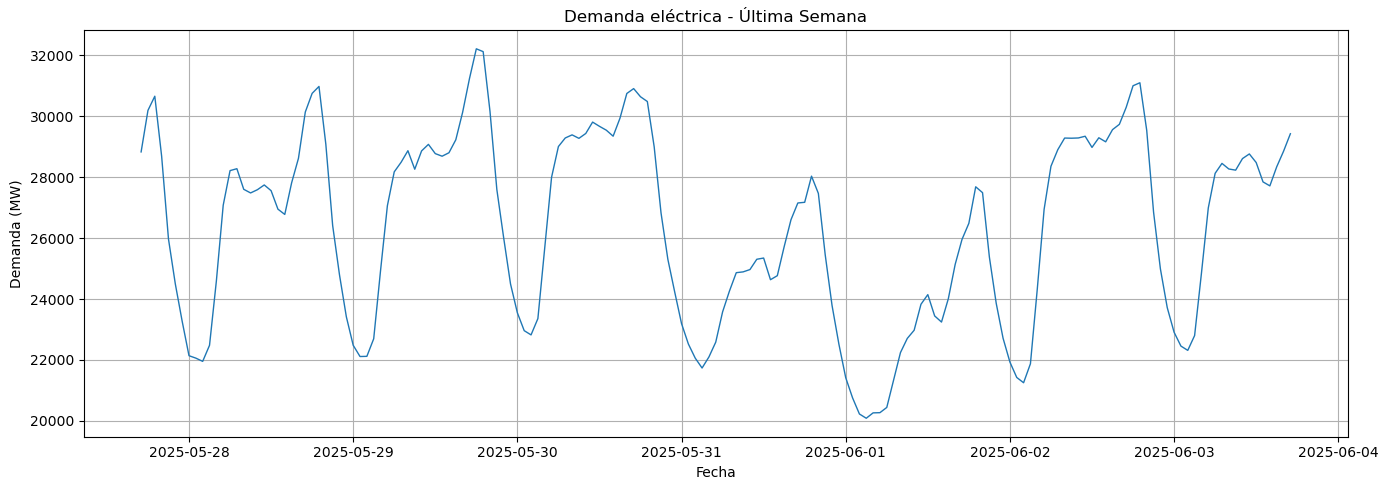

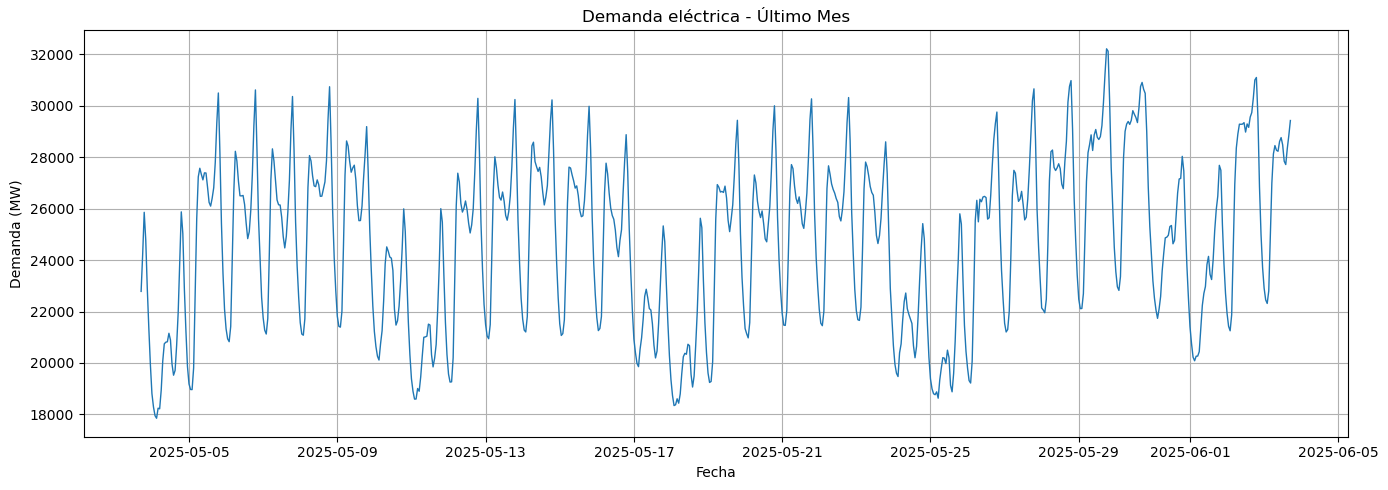

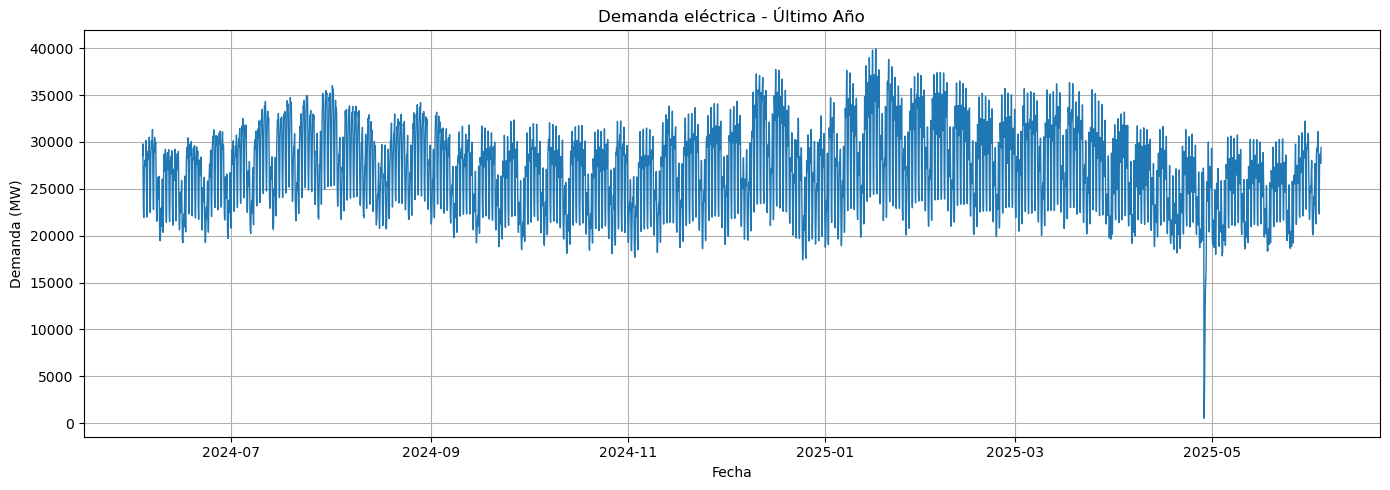

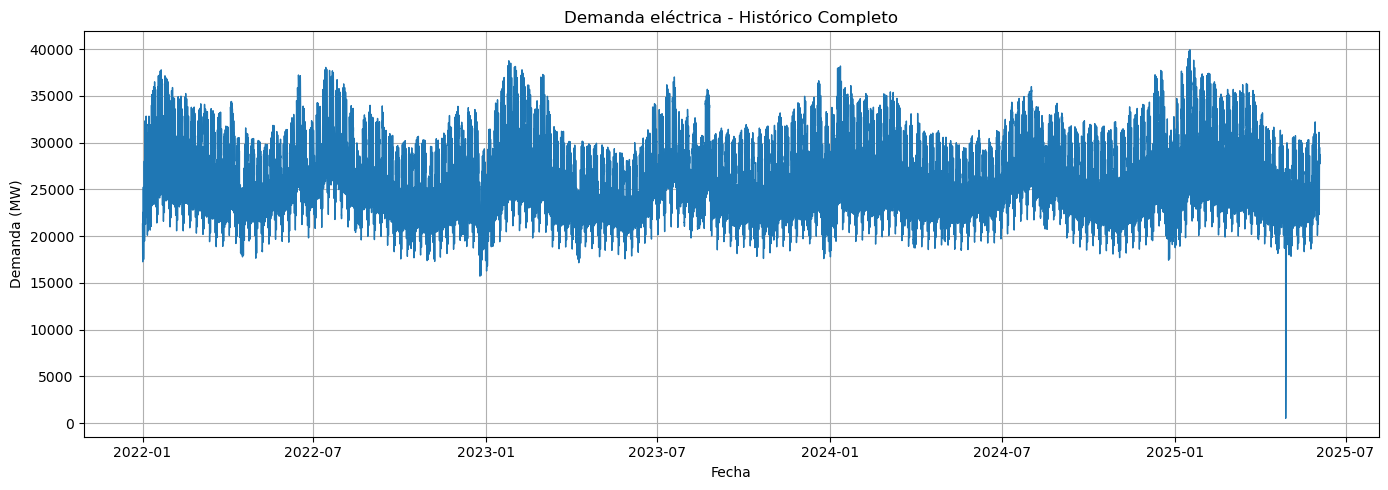

In [28]:
# Visualizaciones
# Series temporales de Demanda Eléctrica

df_hist = df_demanda.copy()
df_1año = df_demanda[df_demanda['datetime'] >= df_demanda['datetime'].max() - pd.DateOffset(years=1)]
df_1mes = df_demanda[df_demanda['datetime'] >= df_demanda['datetime'].max() - pd.DateOffset(months=1)]
df_1sem = df_demanda[df_demanda['datetime'] >= df_demanda['datetime'].max() - pd.DateOffset(weeks=1)]


def graficar(df_filtrado, titulo):
    plt.figure(figsize=(14, 5))
    plt.plot(df_filtrado['datetime'], df_filtrado['value'], linewidth=1)
    plt.title(titulo)
    plt.xlabel("Fecha")
    plt.ylabel("Demanda (MW)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


graficar(df_1sem, "Demanda eléctrica - Última Semana")
graficar(df_1mes, "Demanda eléctrica - Último Mes")
graficar(df_1año, "Demanda eléctrica - Último Año")
graficar(df_hist, "Demanda eléctrica - Histórico Completo")

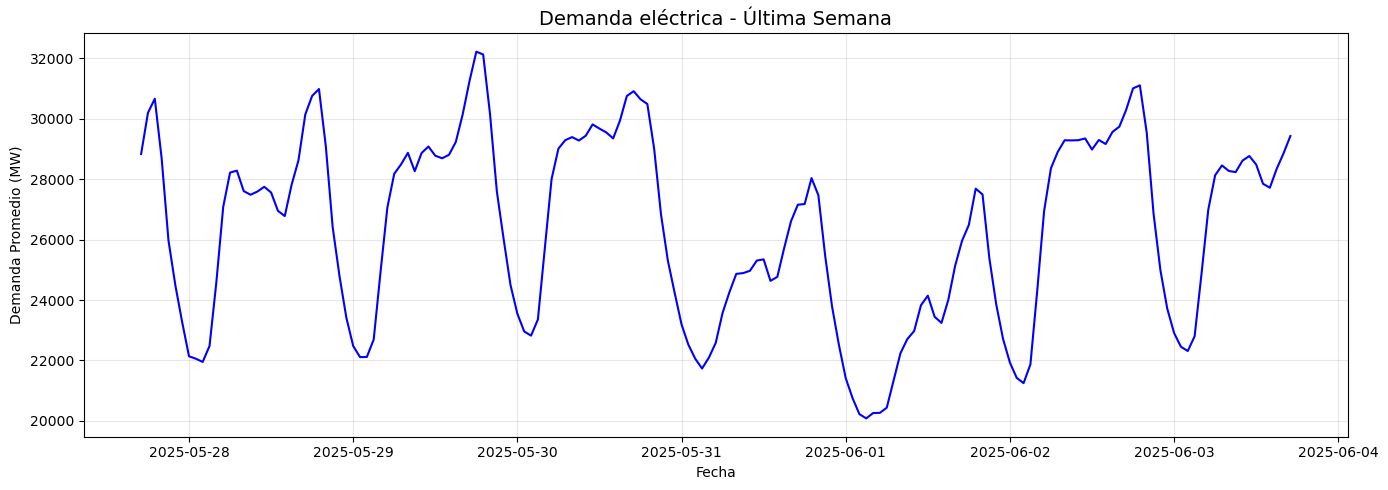

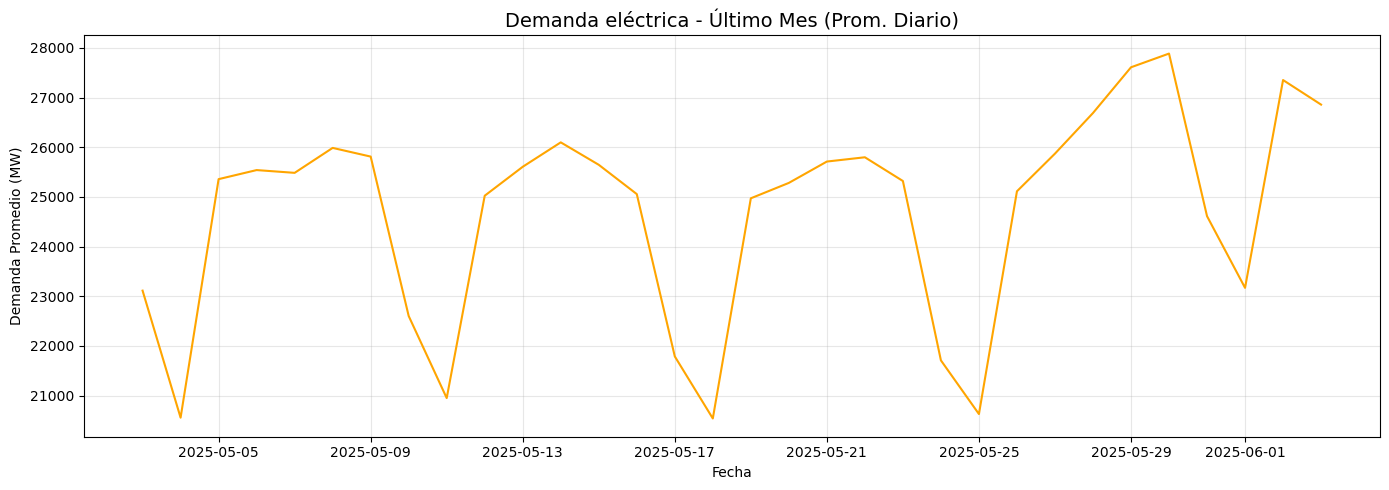

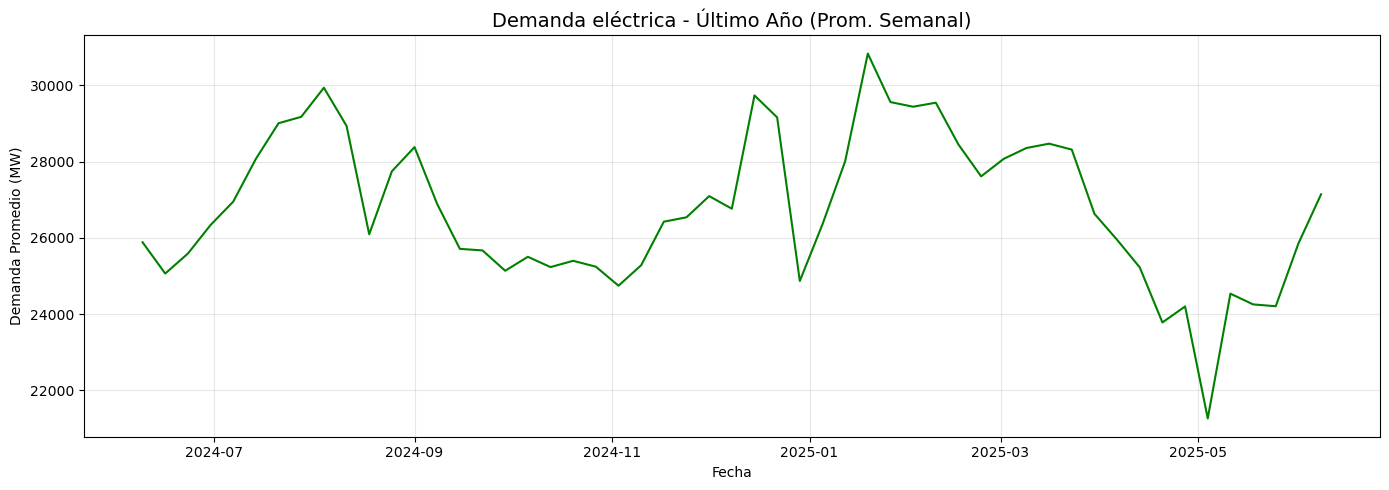

C:\Users\Adri\AppData\Local\Temp\ipykernel_952\807734077.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_resampled = df_temp.set_index('datetime').resample(freq).mean().reset_index()


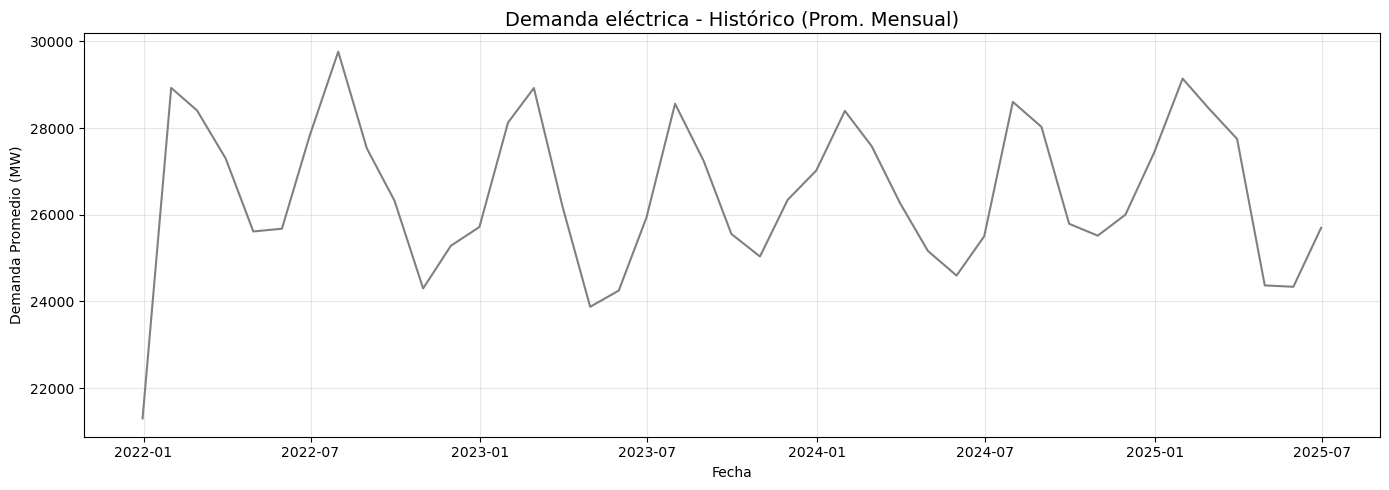

In [50]:
def graficar_resampleado(df_filtrado, titulo, freq, color):
    df_temp = df_filtrado[['datetime', 'value']].copy()  # Asegura que solo trabajamos con 'value'
    df_resampled = df_temp.set_index('datetime').resample(freq).mean().reset_index()

    plt.figure(figsize=(14, 5))
    plt.plot(df_resampled['datetime'], df_resampled['value'], linewidth=1.5, color=color)
    plt.title(titulo, fontsize=14)
    plt.xlabel("Fecha")
    plt.ylabel("Demanda Promedio (MW)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


graficar_resampleado(df_1sem, "Demanda eléctrica - Última Semana", freq='1h', color="blue")
graficar_resampleado(df_1mes, "Demanda eléctrica - Último Mes (Prom. Diario)", freq='1D', color="orange")
graficar_resampleado(df_1año, "Demanda eléctrica - Último Año (Prom. Semanal)", freq='1W', color="green")
graficar_resampleado(df_hist, "Demanda eléctrica - Histórico (Prom. Mensual)", freq='1M', color="gray")




In [30]:
# Mapa Coroplético de Intercambios Eléctricos
df_map = df_intercambios.groupby("primary_category")["value"].sum().reset_index()
df_map.columns = ["pais_original", "Total"]

nombre_map = {
    "francia": "France",
    "portugal": "Portugal",
    "andorra": "Andorra",
    "marruecos": "Morocco"
}
df_map["Country"] = df_map["pais_original"].map(nombre_map)

df_map = df_map.dropna(subset=["Country"])

with open("world_countries_with_andorra.json", "r", encoding="utf-8") as f:
    world_geo = json.load(f)

world_map = folium.Map(location=[40, -3], zoom_start=4)

folium.Choropleth(
    geo_data=world_geo,
    data=df_map,
    columns=["Country", "Total"],
    key_on="feature.properties.name",
    fill_color="RdBu",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Saldo neto de energía (MWh)"
).add_to(world_map)

world_map

C:\Users\Adri\AppData\Local\Temp\ipykernel_952\2625992262.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_compare["day_of_year"] = df_compare["datetime"].dt.dayofyear


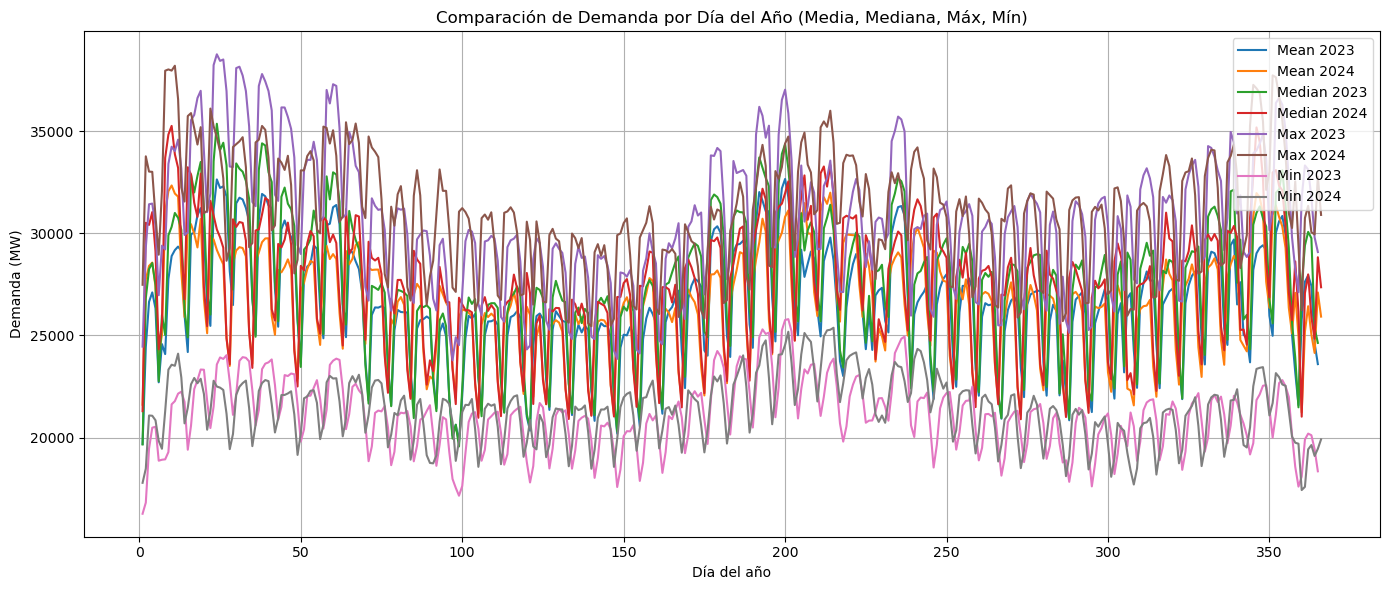

In [32]:
# Comparación de Demanda entre dos años
years_to_compare = [2023, 2024]
df_compare = df_demanda[df_demanda["year"].isin(years_to_compare)]

df_compare["day_of_year"] = df_compare["datetime"].dt.dayofyear

stats = df_compare.groupby(["year", "day_of_year"])["value"].agg(["mean", "median", "max", "min"]).reset_index()

plt.figure(figsize=(14, 6))

for stat in ["mean", "median", "max", "min"]:
    for year in years_to_compare:
        datos = stats[stats["year"] == year]
        plt.plot(datos["day_of_year"], datos[stat], label=f"{stat.capitalize()} {year}")

plt.title("Comparación de Demanda por Día del Año (Media, Mediana, Máx, Mín)")
plt.xlabel("Día del año")
plt.ylabel("Demanda (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

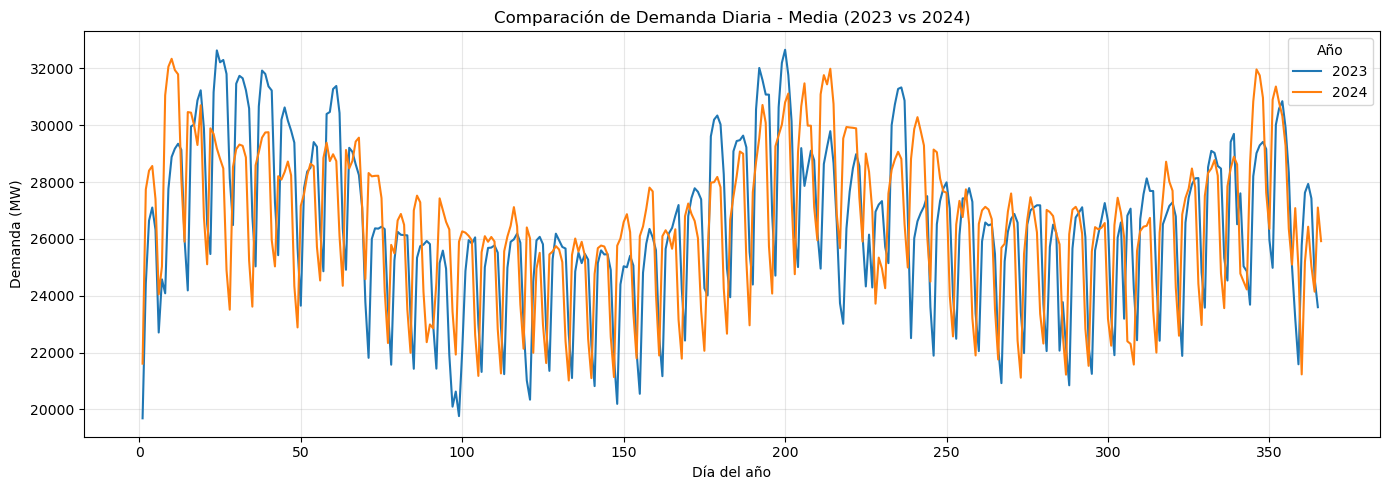

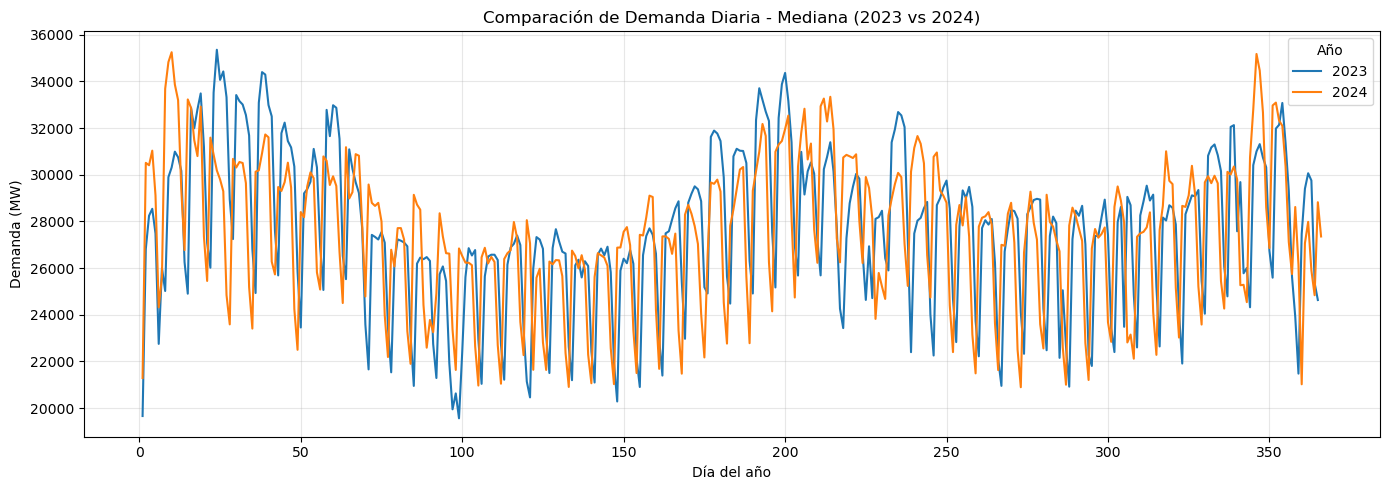

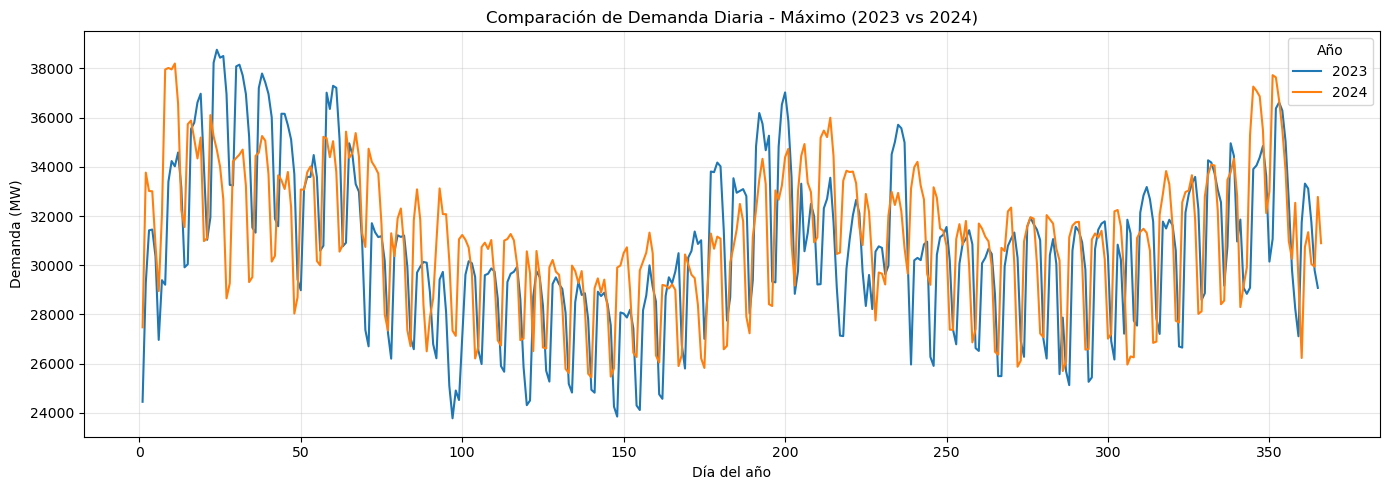

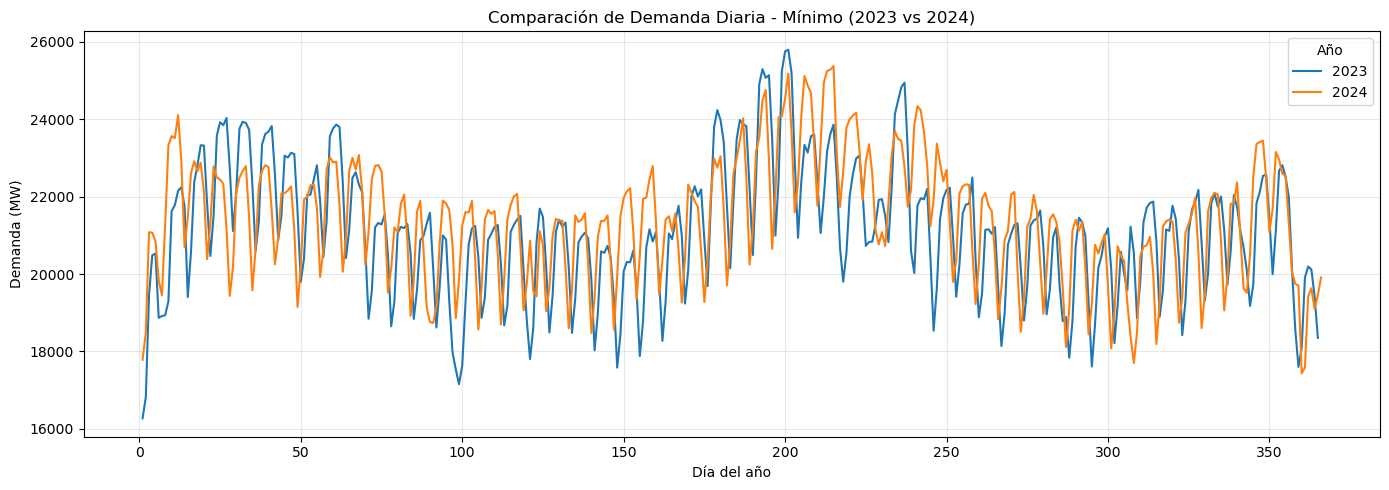

In [52]:
import matplotlib.pyplot as plt


stats = df_compare.groupby(["year", "day_of_year"])["value"].agg(["mean", "median", "max", "min"]).reset_index()


metricas = {
    "mean": "Media",
    "median": "Mediana",
    "max": "Máximo",
    "min": "Mínimo"
}

# Creamos un gráfico por métrica
for metrica, nombre in metricas.items():
    plt.figure(figsize=(14, 5))
    for year in [2023, 2024]:
        datos = stats[stats["year"] == year]
        plt.plot(datos["day_of_year"], datos[metrica], label=f"{year}")
    
    plt.title(f"Comparación de Demanda Diaria - {nombre} (2023 vs 2024)")
    plt.xlabel("Día del año")
    plt.ylabel("Demanda (MW)")
    plt.legend(title="Año")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


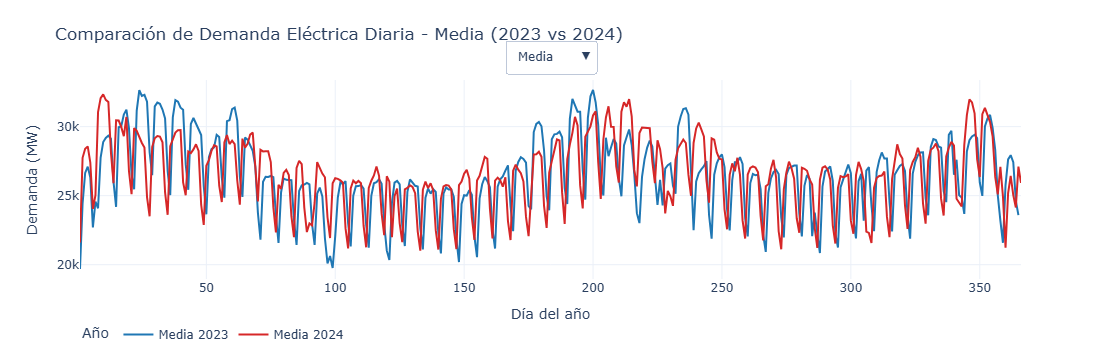

In [58]:
import plotly.graph_objects as go
import pandas as pd


# Filtra solo los años que quieras comparar
years_to_compare = [2023, 2024]
df_compare = df_demanda[df_demanda["year"].isin(years_to_compare)].copy()
df_compare["day_of_year"] = df_compare["datetime"].dt.dayofyear

# Agrupamos por año y día del año, y calculamos las métricas
stats = df_compare.groupby(["year", "day_of_year"])["value"].agg(["mean", "median", "max", "min"]).reset_index()

metricas = ["mean", "median", "max", "min"]
nombres = {"mean": "Media", "median": "Mediana", "max": "Máximo", "min": "Mínimo"}

# Creamos la figura de Plotly
fig = go.Figure()

# Añadimos una línea por cada año y métrica (solo 'mean' visible inicialmente)
for metrica in metricas:
    for year in years_to_compare:
        datos = stats[stats["year"] == year]
        visible = True if metrica == "mean" else False

        fig.add_trace(go.Scatter(
            x=datos["day_of_year"],
            y=datos[metrica],
            mode="lines",
            name=f"{nombres[metrica]} {year}",
            line=dict(
                color="#1f77b4" if year == 2023 else "#d62728",  # Azul y rojo
                dash="solid",  # Ambas líneas continuas
                width=2
            ),
            visible=visible
        ))

# Creamos los botones del dropdown
botones = []
for i, metrica in enumerate(metricas):
    visibilidad = [False] * len(metricas) * len(years_to_compare)
    visibilidad[i * 2] = True     # Año 1
    visibilidad[i * 2 + 1] = True # Año 2

    botones.append(dict(
        label=nombres[metrica],
        method="update",
        args=[{"visible": visibilidad},
              {"title": f"Comparación de Demanda Eléctrica Diaria - {nombres[metrica]} (2023 vs 2024)"}]
    ))

# Ajustes visuales
fig.update_layout(
    title="Comparación de Demanda Eléctrica Diaria - Media (2023 vs 2024)",
    xaxis_title="Día del año",
    yaxis_title="Demanda (MW)",
    updatemenus=[dict(
        active=0,
        buttons=botones,
        x=0.5,
        xanchor="center",
        y=1.2,
        yanchor="top"
    )],
    legend=dict(title="Año", orientation="h", y=-0.2),
    margin=dict(t=80),
    template="plotly_white"
)

# Mostrar gráfico
fig.show()


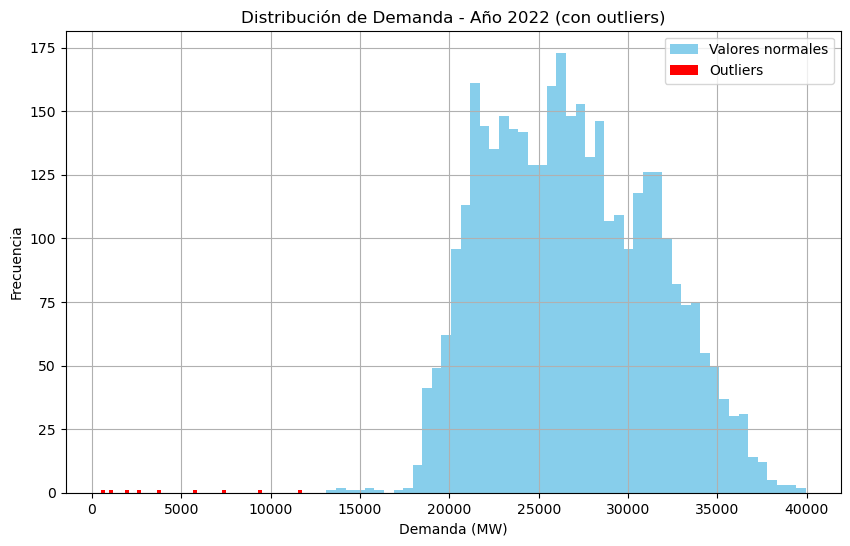

In [34]:
# Outliers de los datos de demanda del año 2025 ( se puede otro año, elegi este, pero se cambia si quereis)
df_2025 = ree_data_df[(ree_data_df["endpoint"] == "demanda") & (ree_data_df["year"] == 2025)]

# Aplicamos Tukey's Fence para identificar outliers
Q1 = df_2025["value"].quantile(0.25)
Q3 = df_2025["value"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

normal_values = df_2025[(df_2025["value"] >= lower_bound) & (df_2025["value"] <= upper_bound)]["value"]
outliers = df_2025[(df_2025["value"] < lower_bound) | (df_2025["value"] > upper_bound)]["value"]


plt.figure(figsize=(10, 6))
plt.hist(normal_values, bins=50, color="skyblue", label="Valores normales")
plt.hist(outliers, bins=50, color="red", label="Outliers")
plt.title("Distribución de Demanda - Año 2022 (con outliers)")
plt.xlabel("Demanda (MW)")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

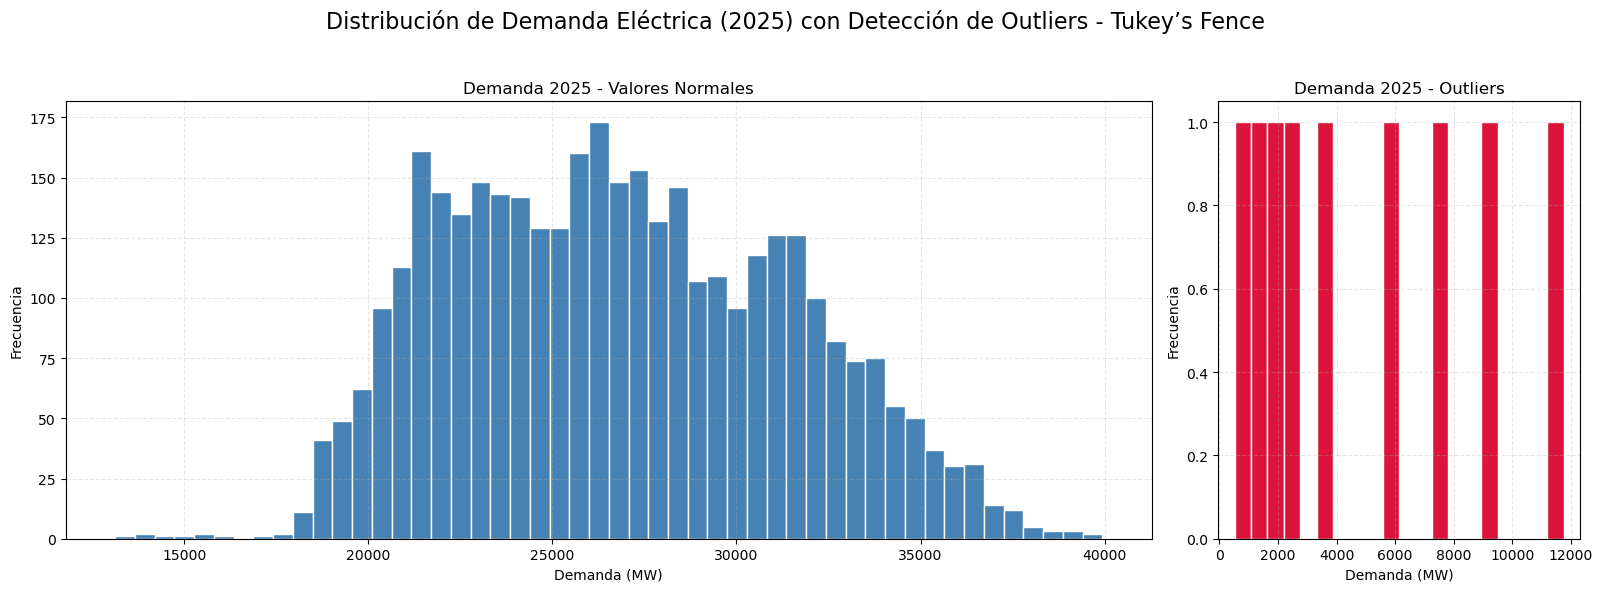

In [60]:
import matplotlib.pyplot as plt

# Filtramos los datos del año 2025
df_2025 = df_demanda[df_demanda["year"] == 2025].copy()

# Calculamos los límites de Tukey's Fence
Q1 = df_2025["value"].quantile(0.25)
Q3 = df_2025["value"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Separamos normales y outliers
normal_values = df_2025[(df_2025["value"] >= lower_bound) & (df_2025["value"] <= upper_bound)]["value"]
outliers = df_2025[(df_2025["value"] < lower_bound) | (df_2025["value"] > upper_bound)]["value"]

# Creamos subgráficos
fig, axs = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [3, 1]})

# Histograma de valores normales
axs[0].hist(normal_values, bins=50, color="steelblue", edgecolor='white')
axs[0].set_title("Demanda 2025 - Valores Normales")
axs[0].set_xlabel("Demanda (MW)")
axs[0].set_ylabel("Frecuencia")
axs[0].grid(True, linestyle='--', alpha=0.3)

# Histograma de outliers
axs[1].hist(outliers, bins=20, color="crimson", edgecolor='white')
axs[1].set_title("Demanda 2025 - Outliers")
axs[1].set_xlabel("Demanda (MW)")
axs[1].set_ylabel("Frecuencia")
axs[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle("Distribución de Demanda Eléctrica (2025) con Detección de Outliers - Tukey’s Fence", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#########ojo que este la parte fea es que outliers llega a 1 y parece igual de grande que la de los valores normales que llegan a 175, no supe corregir eso

In [36]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


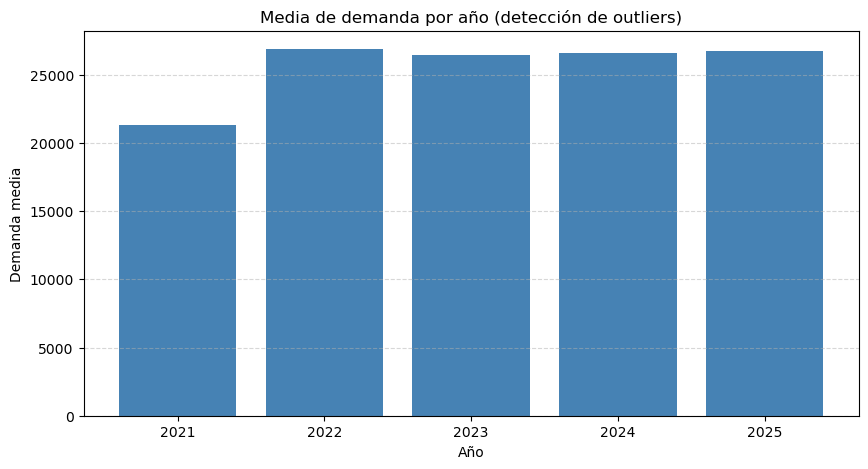

In [38]:
# Años outliers
from scipy.stats import zscore

yearly_avg = df_demanda.groupby("year")["value"].mean().reset_index()
yearly_avg.columns = ["year", "avg_demand"]

yearly_avg["z_score"] = zscore(yearly_avg["avg_demand"])

yearly_avg["is_outlier"] = yearly_avg["z_score"].abs() > 2

plt.figure(figsize=(10, 5))
colors = ["red" if is_outlier else "steelblue" for is_outlier in yearly_avg["is_outlier"]]
plt.bar(yearly_avg["year"], yearly_avg["avg_demand"], color=colors)
plt.title("Media de demanda por año (detección de outliers)")
plt.xlabel("Año")
plt.ylabel("Demanda media")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

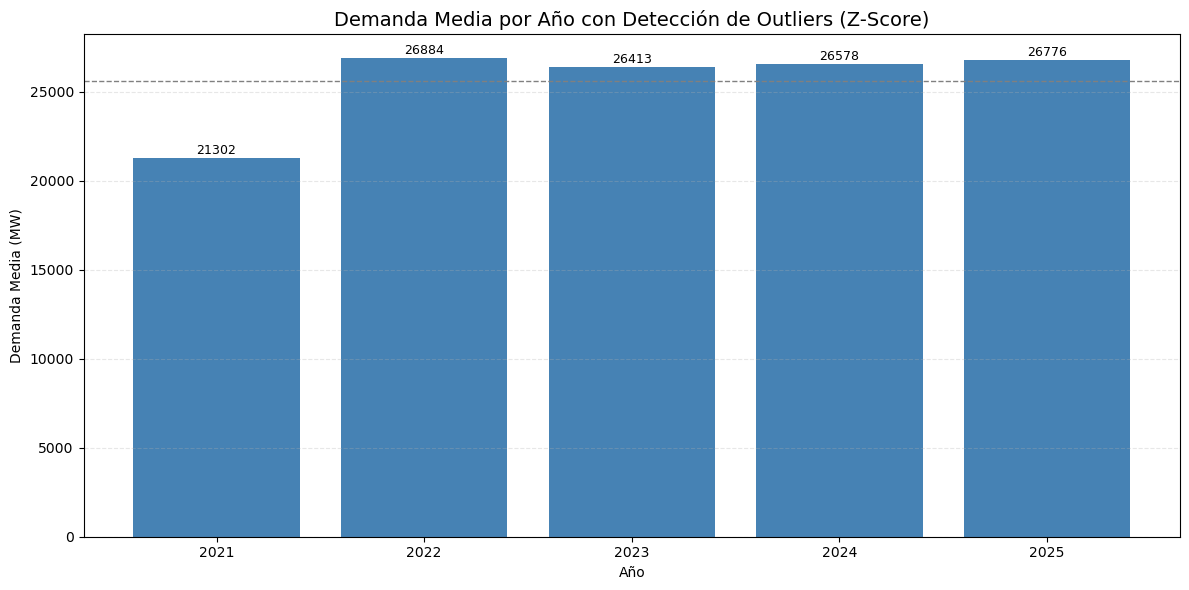

In [62]:
from scipy.stats import zscore
import matplotlib.pyplot as plt

# Agrupamos por año y calculamos la media de demanda
yearly_avg = df_demanda.groupby("year")["value"].mean().reset_index()
yearly_avg.columns = ["year", "avg_demand"]

# Calculamos Z-Score
yearly_avg["z_score"] = zscore(yearly_avg["avg_demand"])

# Marcamos outliers
yearly_avg["is_outlier"] = yearly_avg["z_score"].abs() > 2

# Ordenamos para mejor visualización
yearly_avg = yearly_avg.sort_values("avg_demand", ascending=False)

# Colores: rojo para outliers, azul para normales
colors = ["crimson" if is_outlier else "steelblue" for is_outlier in yearly_avg["is_outlier"]]

# Graficamos
plt.figure(figsize=(12, 6))
bars = plt.bar(yearly_avg["year"], yearly_avg["avg_demand"], color=colors)

# Etiquetas en cada barra
for bar, valor in zip(bars, yearly_avg["avg_demand"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{valor:.0f}", ha='center', va='bottom', fontsize=9)

# Línea horizontal de media general
plt.axhline(yearly_avg["avg_demand"].mean(), color='gray', linestyle='--', linewidth=1)

plt.title("Demanda Media por Año con Detección de Outliers (Z-Score)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Demanda Media (MW)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


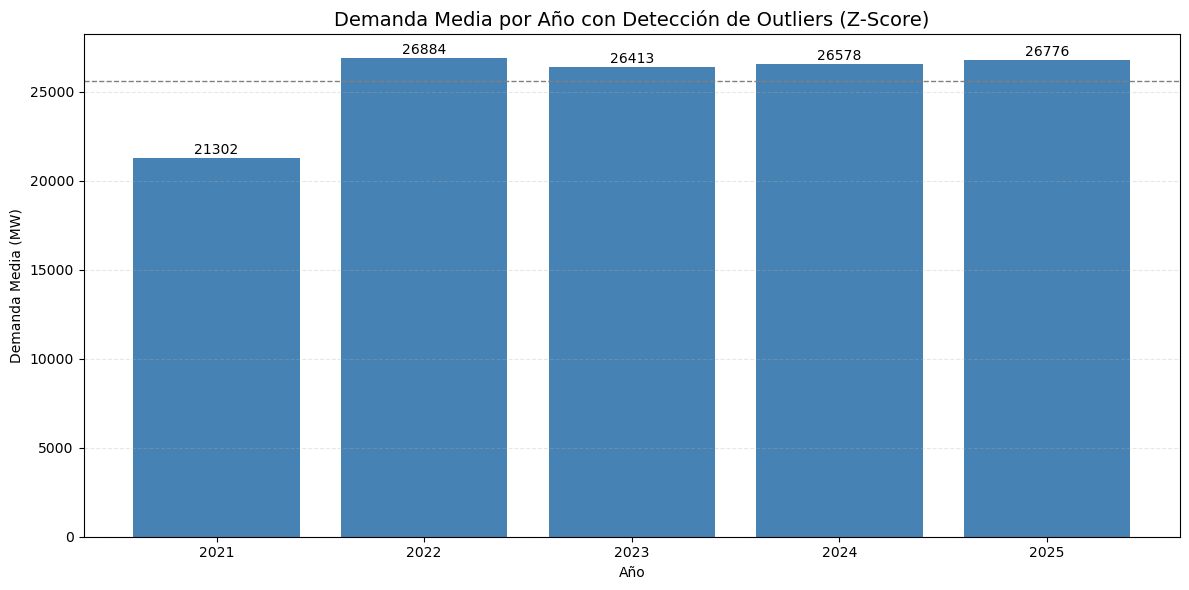

In [78]:
plt.figure(figsize=(12, 6))
bars = plt.bar(yearly_avg["year"], yearly_avg["avg_demand"], color=colors)

for bar, valor, is_out in zip(bars, yearly_avg["avg_demand"], yearly_avg["is_outlier"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{valor:.0f}" + ("" if is_out else ""), ha='center', va='bottom', fontsize=10,
             fontweight="bold" if is_out else "normal", color="crimson" if is_out else "black")

plt.axhline(yearly_avg["avg_demand"].mean(), color='gray', linestyle='--', linewidth=1)
plt.title("Demanda Media por Año con Detección de Outliers (Z-Score)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Demanda Media (MW)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


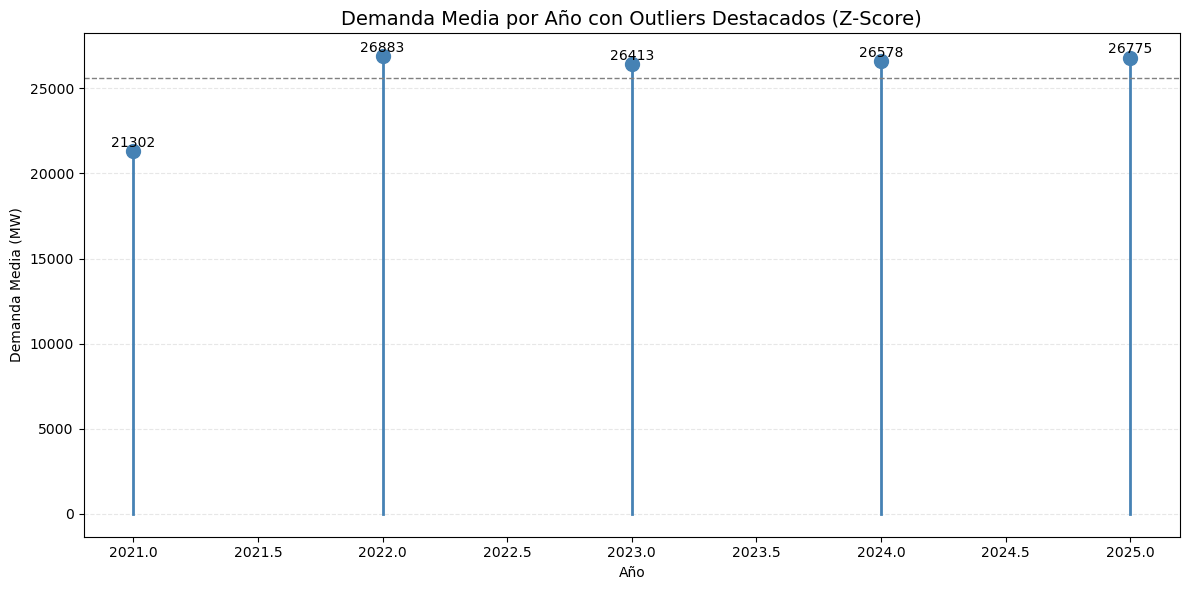

In [80]:
plt.figure(figsize=(12, 6))

for i, row in yearly_avg.iterrows():
    color = "crimson" if row["is_outlier"] else "steelblue"
    plt.plot([row["year"], row["year"]], [0, row["avg_demand"]], color=color, linewidth=2)
    plt.plot(row["year"], row["avg_demand"], 'o', color=color, markersize=10)
    label = f"{int(row['avg_demand'])}" + ("" if row["is_outlier"] else "")
    plt.text(row["year"], row["avg_demand"] + 100, label, ha='center', va='bottom', fontsize=10)

plt.axhline(yearly_avg["avg_demand"].mean(), color='gray', linestyle='--', linewidth=1)
plt.title("Demanda Media por Año con Outliers Destacados (Z-Score)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Demanda Media (MW)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


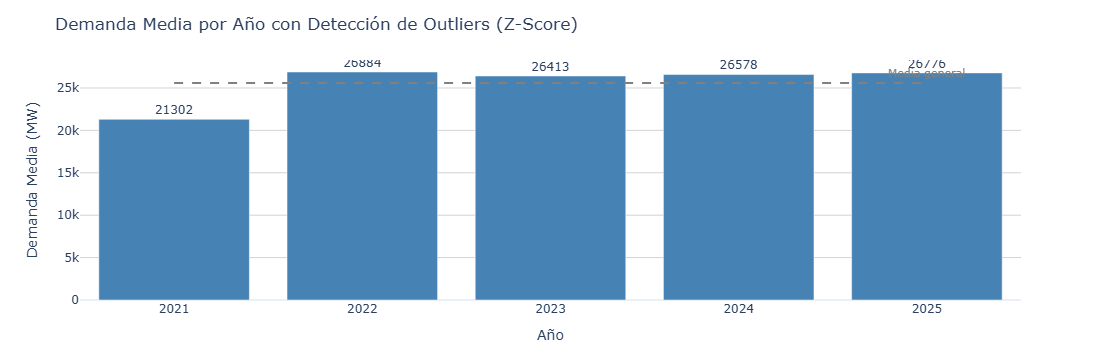

In [82]:
import plotly.graph_objects as go
from scipy.stats import zscore

# Agrupar por año y calcular demanda media
yearly_avg = df_demanda.groupby("year")["value"].mean().reset_index()
yearly_avg.columns = ["year", "avg_demand"]
yearly_avg["z_score"] = zscore(yearly_avg["avg_demand"])
yearly_avg["is_outlier"] = yearly_avg["z_score"].abs() > 2

# Colores
yearly_avg["color"] = yearly_avg["is_outlier"].apply(lambda x: "crimson" if x else "steelblue")

# Crear figura
fig = go.Figure()

fig.add_trace(go.Bar(
    x=yearly_avg["year"],
    y=yearly_avg["avg_demand"],
    marker_color=yearly_avg["color"],
    text=yearly_avg["avg_demand"].round(0),
    textposition="outside",
    hovertemplate='Año: %{x}<br>Demanda Media: %{y:.0f} MW<extra></extra>'
))

# Línea horizontal de media general
media_general = yearly_avg["avg_demand"].mean()
fig.add_shape(type="line",
              x0=yearly_avg["year"].min(), x1=yearly_avg["year"].max(),
              y0=media_general, y1=media_general,
              line=dict(color="gray", dash="dash"))

fig.add_annotation(x=yearly_avg["year"].max(),
                   y=media_general,
                   text="Media general",
                   showarrow=False,
                   yshift=10,
                   font=dict(size=11, color="gray"))

fig.update_layout(
    title="Demanda Media por Año con Detección de Outliers (Z-Score)",
    xaxis_title="Año",
    yaxis_title="Demanda Media (MW)",
    template="plotly_white",
    yaxis=dict(gridcolor='lightgray'),
    margin=dict(t=60, b=60)
)

fig.show()


C:\Users\Adri\AppData\Local\Temp\ipykernel_952\4186795512.py:3: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



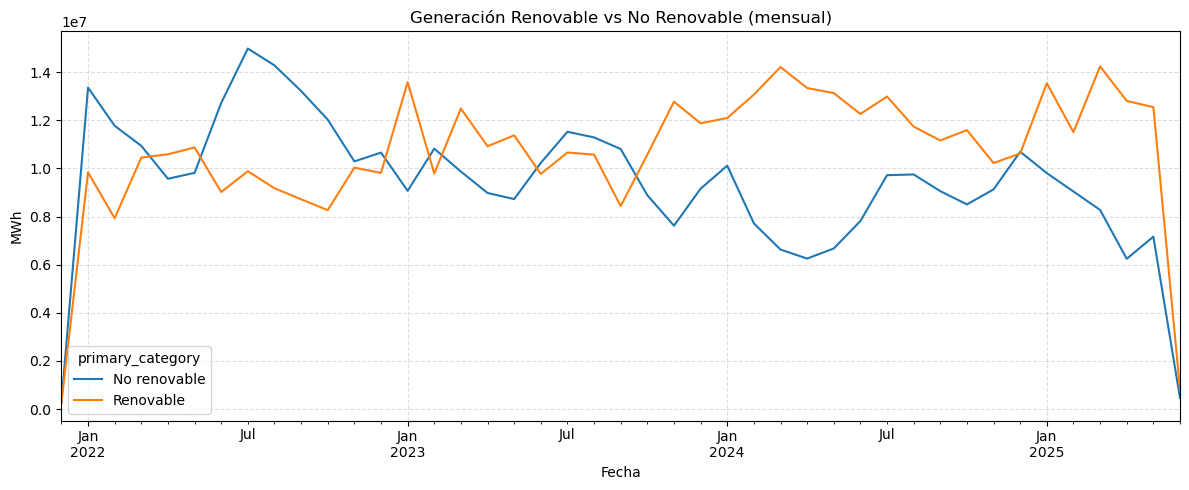

In [76]:
# Evolución de la generación renovable vs no renovable

df_monthly = (df_generacion.groupby([df_generacion["datetime"].dt.to_period("M"), "primary_category"])["value"].sum().unstack().fillna(0))

df_monthly.index = df_monthly.index.to_timestamp()

df_monthly.plot(figsize=(12, 5), title="Generación Renovable vs No Renovable (mensual)")
plt.ylabel("MWh")
plt.xlabel("Fecha")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
df_monthly_saldo = (df_intercambios.copy()).groupby(pd.Grouper(key="datetime", freq="ME"))["value"].sum()

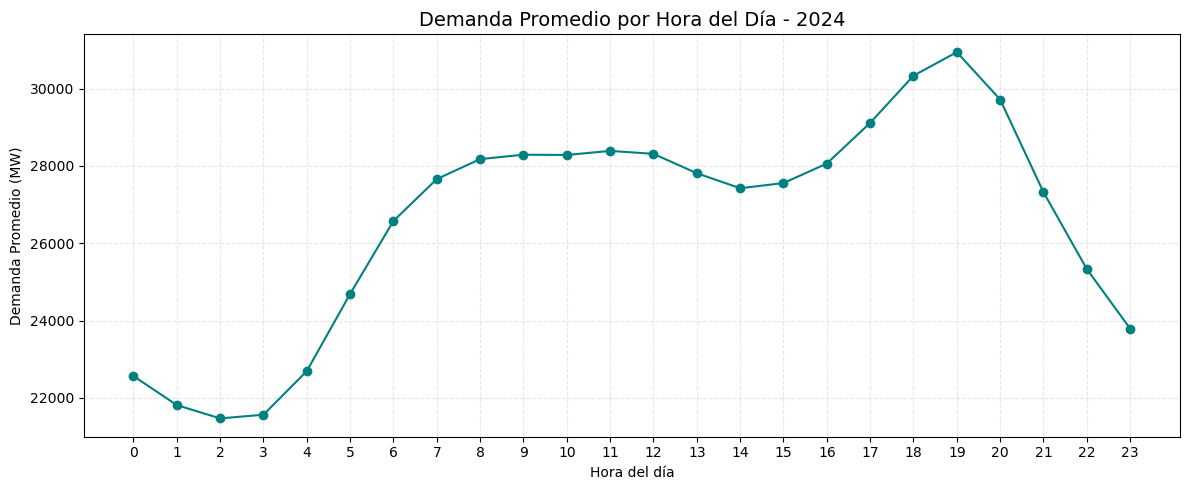

In [70]:
df_2024 = df_demanda[df_demanda["year"] == 2024].copy()
df_2024["hour"] = df_2024["datetime"].dt.hour

# Promedio por hora
avg_hourly = df_2024.groupby("hour")["value"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(avg_hourly["hour"], avg_hourly["value"], marker='o', color='teal')
plt.title("Demanda Promedio por Hora del Día - 2024", fontsize=14)
plt.xlabel("Hora del día")
plt.ylabel("Demanda Promedio (MW)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


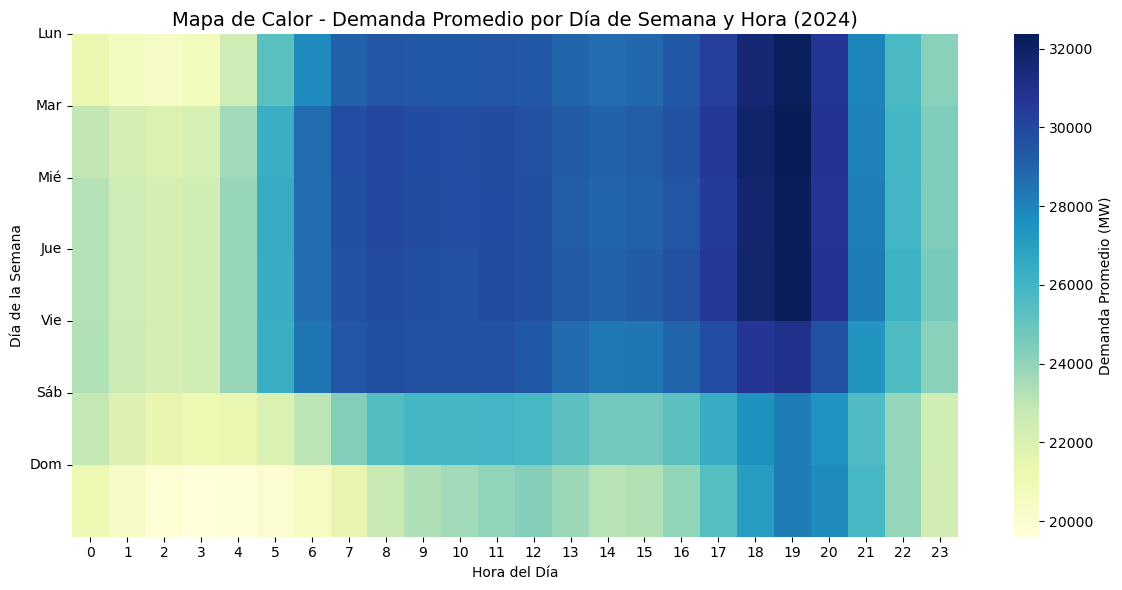

In [72]:
import seaborn as sns

df_2024 = df_demanda[df_demanda["year"] == 2024].copy()
df_2024["day_of_week"] = df_2024["datetime"].dt.dayofweek  # Lunes=0, Domingo=6
df_2024["hour"] = df_2024["datetime"].dt.hour

pivot = df_2024.pivot_table(values='value', index='day_of_week', columns='hour', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="YlGnBu", annot=False, cbar_kws={'label': 'Demanda Promedio (MW)'})
plt.title("Mapa de Calor - Demanda Promedio por Día de Semana y Hora (2024)", fontsize=14)
plt.xlabel("Hora del Día")
plt.ylabel("Día de la Semana")
plt.yticks(ticks=range(7), labels=["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"], rotation=0)
plt.tight_layout()
plt.show()
